# Experiment 1 — statistical analysis (PD)

How do the learners compare on **PD** (metric: **AUC**), across datasets, in a statistically defensible way? We follow Demšar (2006) and its successors, and read the evidence as a story:

1. **PAMA** — who wins most often (descriptive).
2. **Omnibus tests** — do the methods differ *at all*?
3. **Critical-difference diagram** — which groups are indistinguishable.
4. **Win/Loss matrix** — the direction of every head-to-head.
5. **Significant pairs** — which differences survive multiple-comparison correction.
6. **Adjusted-p-value matrix** — the same, as a colour map.
7. **Bayesian ROPE analysis** — the *practical* probability of superiority.

All logic lives in `src/utils/statistical_testing.py`; this notebook only narrates and calls it.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import apply_style, reset_figure_dir, load_summary
from src.methods.method_config import FOUNDATION_METHODS
from src.utils import statistical_testing as st
apply_style()

RESULTS_ROOT = results_root()
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1' / 'pd_stats')
FND = sorted(FOUNDATION_METHODS)
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment1\pd_stats


In [2]:
df       = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd')
df_folds = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd', aggregated=False)
mat  = st.metric_matrix(df, 'AUC')
ranks = st.average_ranks(mat)              # best-first ordering reused everywhere
print(f'PD: {mat.shape[1]} methods x {mat.shape[0]} datasets')

[stat] dropping methods with missing datasets: ['autoint', 'tabpfn_real', 'tabpfn_v2']
PD: 31 methods x 14 datasets


## 1. PAMA — how often is each learner the single best?

**What it is.** For every fold-level observation (each dataset × fold), we ask which method scored highest, and count how often each method wins. **Why it matters.** It is a direct, assumption-free measure of *practical dominance* — robust to one or two outlying datasets and needing no model of the score distribution. **How to read it.** Taller bar = wins more often; foundation models are in red, and their *collective* share is annotated.

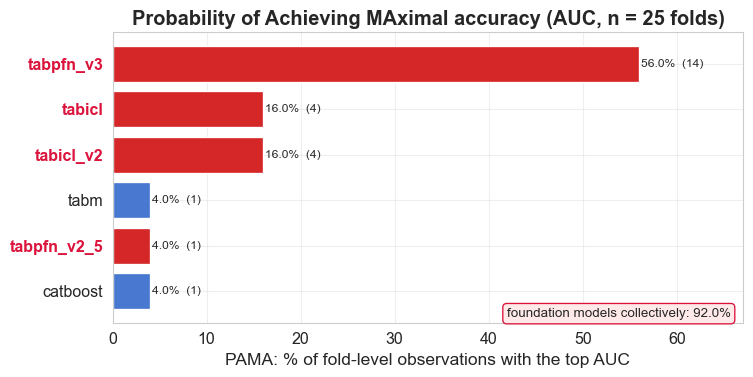

,wins,n_folds,PAMA_%
method,,,
tabpfn_v3,14,25,56.0
tabicl,4,25,16.0
tabicl_v2,4,25,16.0
tabm,1,25,4.0
tabpfn_v2_5,1,25,4.0
catboost,1,25,4.0
LogReg,0,25,0.0
switchtab,0,25,0.0
t2gformer,0,25,0.0


In [3]:
st.plot_pama_bars(df_folds, 'AUC', metric_name='AUC', foundation_methods=FND,
                  out_path=FIGURES_DIR / 'pd_pama.pdf')
display(st.pama_fold_level(df_folds, 'AUC').head(12))

## 2. Do the methods differ at all? — Friedman omnibus test

**What it is.** PAMA is descriptive; it cannot tell us whether the differences are real or chance. The Friedman test ranks the methods within each dataset and tests whether the *average ranks* depart from what equal methods would produce; the **Iman–Davenport** correction turns it into a less-conservative F-test. **How to read it.** A small p-value rejects "all methods are equal", which licenses the pairwise post-hocs that follow.

In [4]:
f = st.friedman_test(mat)
print(f"N={f['N']} datasets, k={f['k']} methods")
print(f"Friedman/Iman-Davenport: F_F = {f['iman_davenport_F']:.2f}, p = {f['p_iman_davenport']:.3g}")

N=14 datasets, k=31 methods
Friedman/Iman-Davenport: F_F = 18.08, p = 1.79e-56


## 3. More powerful omnibus alternatives — Aligned Ranks & Quade

**Why.** With many methods but few datasets, the plain Friedman test loses power. The **Friedman Aligned Ranks** test (rank all observations after removing each dataset's mean) and the **Quade** test (weight each dataset by how much it discriminates) recover power (García et al., 2010). **How to read it.** If these agree with Friedman, the global signal is robust to the choice of test.

In [5]:
fa = st.friedman_aligned_ranks_test(mat); qu = st.quade_test(mat)
print(f"Aligned Ranks: chi2 = {fa['aligned_ranks_chi2']:.1f}, p = {fa['p']:.3g}")
print(f"Quade:         F   = {qu['quade_F']:.2f}, p = {qu['p']:.3g}")

Aligned Ranks: chi2 = 218.5, p = 1.64e-30
Quade:         F   = 12.68, p = 2.78e-41


## 4. Which methods are indistinguishable? — critical-difference diagram

**What it is.** Methods are placed on the average-rank axis (rank 1 = best, on the left). Any two methods whose ranks differ by less than the **critical difference (CD)** are *not* significantly different (Nemenyi, α = 0.05) and are joined by a bold bar. **How to read it.** Bold bars are "cliques" of statistically tied methods; foundation models are in red.

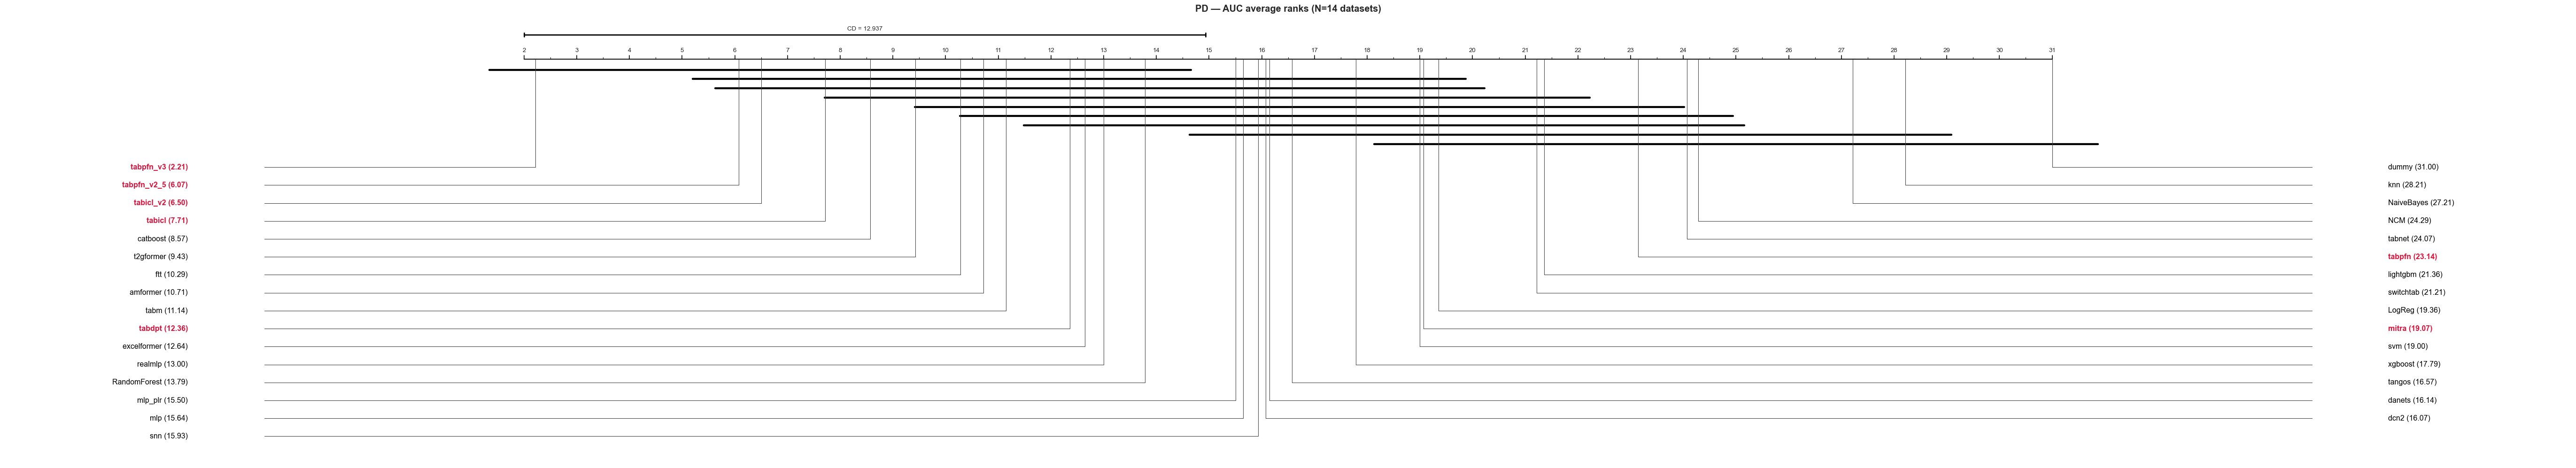

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd_stats/pd_cd_auc.pdf')

In [6]:
st.plot_cd_diagram(ranks, st.nemenyi_cd(mat.shape[1], mat.shape[0]),
                   title=f'PD — AUC average ranks (N={mat.shape[0]} datasets)',
                   out_path=FIGURES_DIR / 'pd_cd_auc.pdf')

[stat] dropping methods with missing datasets: ['autoint', 'tabpfn_real', 'tabpfn_v2']


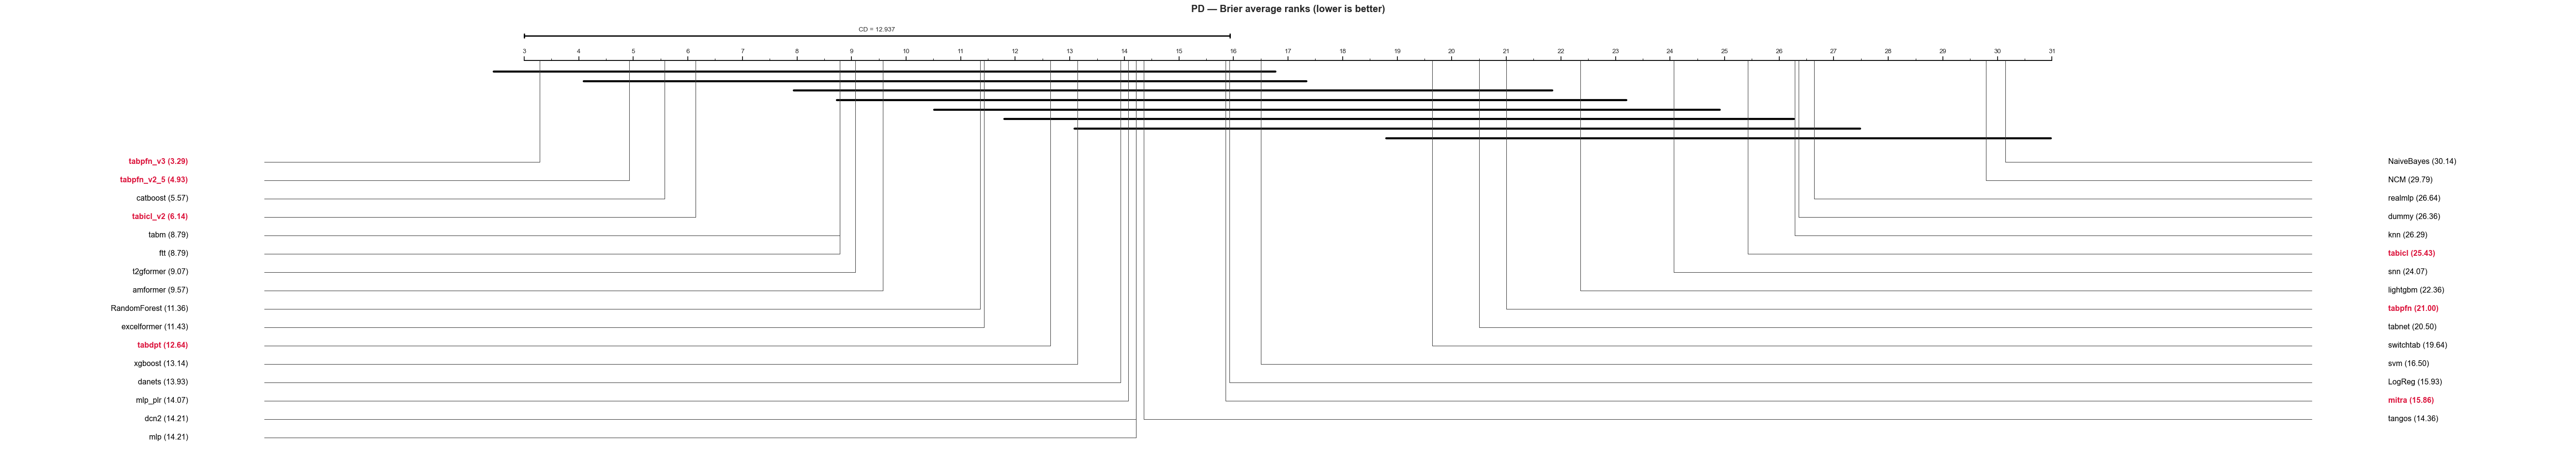

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd_stats/pd_cd_brier.pdf')

In [7]:
mat2 = st.metric_matrix(df, 'Brier')
st.plot_cd_diagram(st.average_ranks(mat2, higher_is_better=False),
                   st.nemenyi_cd(mat2.shape[1], mat2.shape[0]),
                   title='PD — Brier average ranks (lower is better)',
                   out_path=FIGURES_DIR / 'pd_cd_brier.pdf')

## 5. Every head-to-head — Win/Loss matrix

**What it is.** For each ordered pair, the number of datasets the row method beats the column method (cell text = Win/Loss; colour = win−loss margin). **Why it matters.** It shows the *direction and consistency* of each duel regardless of significance — a method can win most datasets yet not be significant, and vice-versa. Rows/columns are ordered best-first.

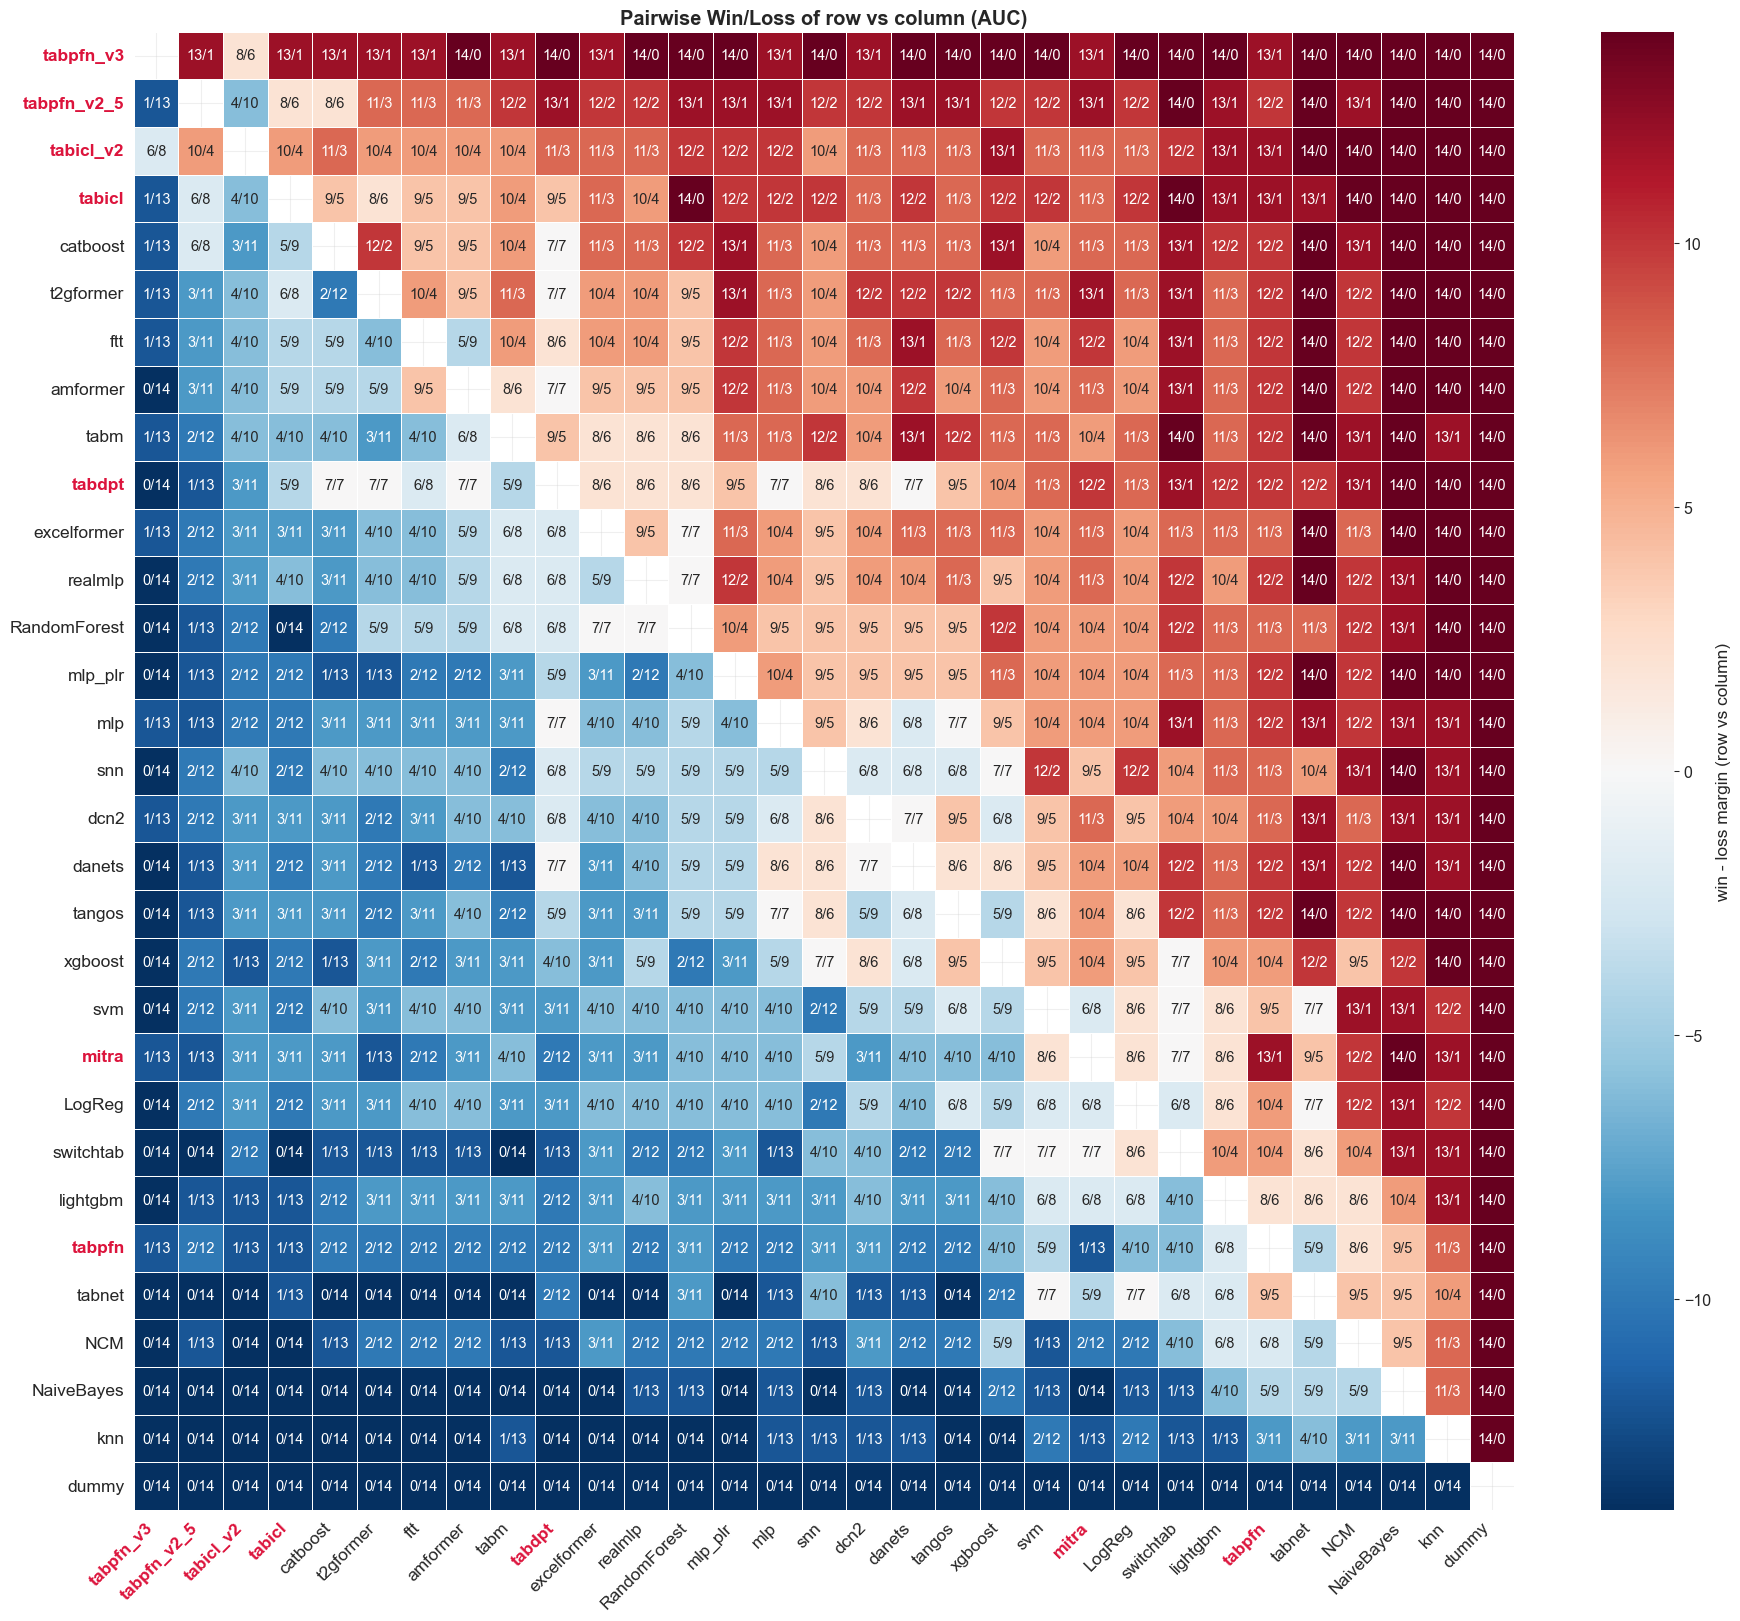

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd_stats/pd_winloss.pdf')

In [8]:
st.plot_wilcoxon_wl_matrix(mat, metric_name='AUC',
                           out_path=FIGURES_DIR / 'pd_winloss.pdf')

## 6. Which differences are significant? — Wilcoxon + Holm

**What it is.** Each pair is tested with the Wilcoxon signed-rank test (non-parametric, uses the magnitude *and* direction of per-dataset differences), and p-values are **Holm-corrected** across all pairs to control the family-wise error. **How to read it.** Only the pairs that remain significant are listed. With many methods the correction is strict, so a short list is expected — it does **not** contradict a significant omnibus test, which has far more power to detect global heterogeneity than pairwise tests have to localise it.

In [9]:
st.significant_pairs_text(mat, metric_name='AUC')

Significant pairwise differences in AUC (Wilcoxon signed-rank, Holm-corrected, alpha = 0.05):
  0 of 465 pairs significant.

  (none reach significance after Holm correction)


'Significant pairwise differences in AUC (Wilcoxon signed-rank, Holm-corrected, alpha = 0.05):\n  0 of 465 pairs significant.\n\n  (none reach significance after Holm correction)'

## 7. The same, as a colour map — adjusted-p-value matrix

**What it is.** For every pair, the **Shaffer-adjusted** p-value of the rank difference. Shaffer's static procedure exploits the logical dependencies among the hypotheses (if A=B and B=C then A=C cannot be free) to be less conservative than Holm while still controlling the family-wise error. **How to read it.** A **green** cell means that pair differs significantly (adjusted p < 0.05); red means it does not. Methods are ordered best-first; foundation models are in red.

[stat] Bergmann-Hommel skipped (k=31 > 8; exhaustive-set enumeration infeasible) -- use Shaffer instead.


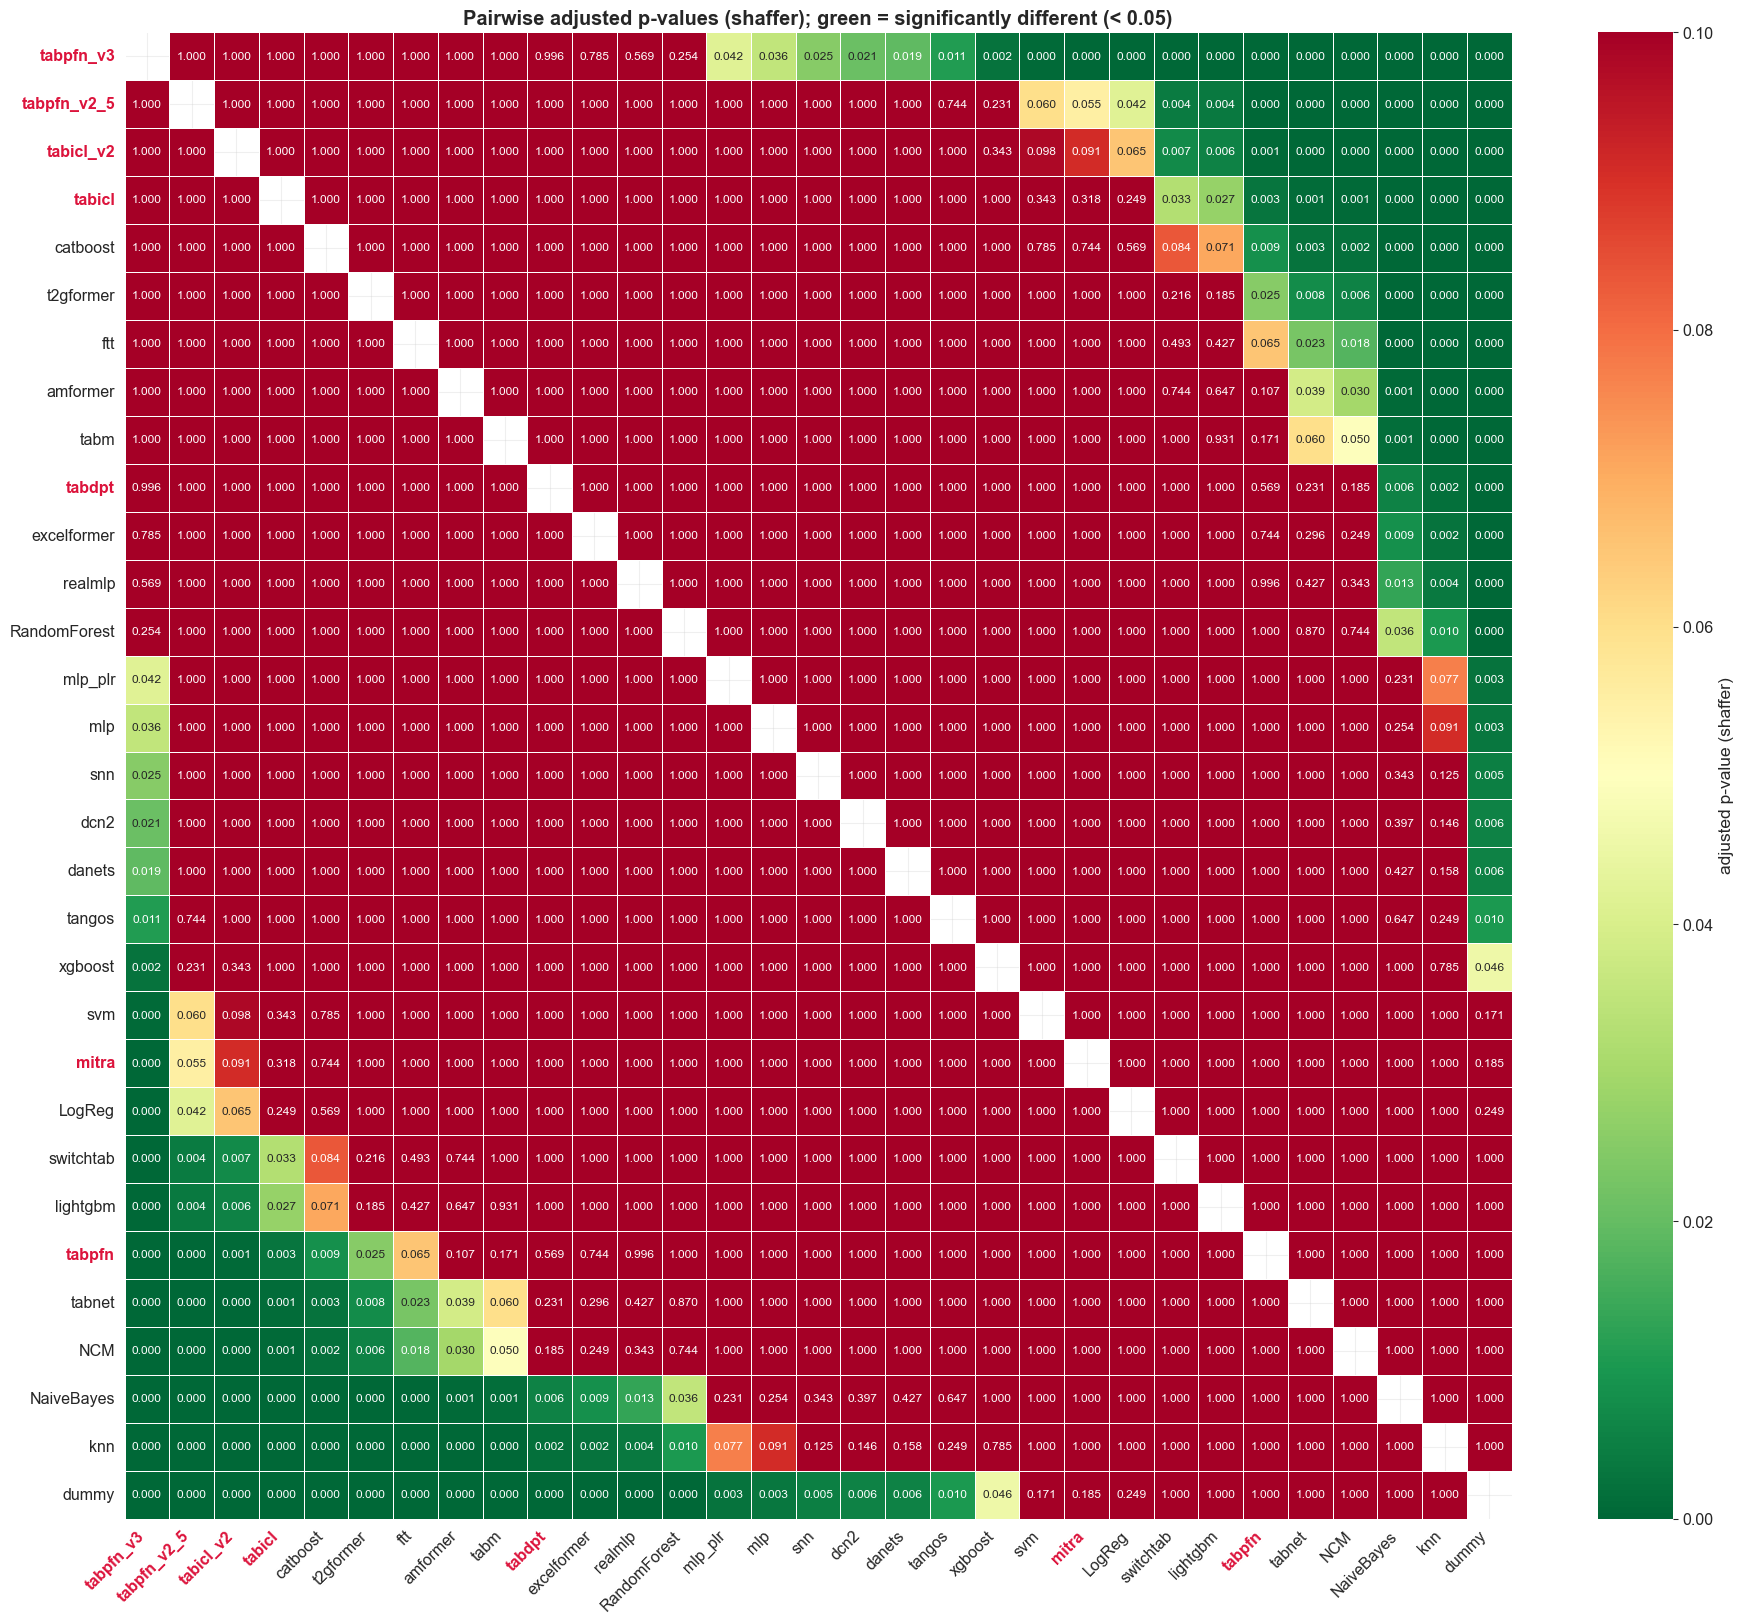

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd_stats/pd_significance.pdf')

In [10]:
apv = st.pairwise_apv_table(mat)
st.plot_significance_matrix(apv, mat.columns, order=list(ranks.index),
                            out_path=FIGURES_DIR / 'pd_significance.pdf')

## 8. The practical question — Bayesian analysis with a ROPE

**Why.** Classical tests answer "is there *any* difference?". For deployment we care whether a difference is *large enough to matter*. The **Bayesian sign test** (Benavoli et al., 2017) defines a **region of practical equivalence (ROPE)** and returns the posterior probability that one method is practically better, that they are equivalent, or that the other is better. **It needs no family-wise correction**, which is a genuine advantage when this many methods are compared. Below: the two top-ranked methods, and the best foundation model vs the best non-foundation method.

In [11]:
m1, m2 = ranks.index[0], ranks.index[1]
r = st.bayesian_sign_test(mat[m1], mat[m2], rope=0.01)
print(f'{m1} vs {m2} (ROPE=0.01):  P({m1} better)={r["P_right"]:.3f}  '
      f'P(equivalent)={r["P_rope"]:.3f}  P({m2} better)={r["P_left"]:.3f}')
fb = next((m for m in ranks.index if m in set(FND)), None)
ob = next((m for m in ranks.index if m not in set(FND)), None)
if fb and ob:
    r2 = st.bayesian_sign_test(mat[fb], mat[ob], rope=0.01)
    print(f'{fb} (foundation) vs {ob}:  P({fb} better)={r2["P_right"]:.3f}  '
          f'P(equivalent)={r2["P_rope"]:.3f}  P({ob} better)={r2["P_left"]:.3f}')

tabpfn_v3 vs tabpfn_v2_5 (ROPE=0.01):  P(tabpfn_v3 better)=0.156  P(equivalent)=0.822  P(tabpfn_v2_5 better)=0.022
tabpfn_v3 (foundation) vs catboost:  P(tabpfn_v3 better)=0.489  P(equivalent)=0.489  P(catboost better)=0.022


> **The story in one line.** PAMA shows who wins most; the omnibus tests confirm the differences are real; the CD diagram and Win/Loss matrix show *who* and *by how much*; Holm-corrected Wilcoxon isolates the few rigorously-significant pairs; and the Bayesian ROPE analysis turns that into the practical probability of superiority.